# Demand Forecasting for Inventory Planning — UCI Online Retail II

**Goal.** Forecast **aggregate unit demand** for inventory planning on the
UCI Online Retail II dataset (id 502), using the same two-track design as the
Superstore notebook:

1. **Part 1 — PyCaret 4.x time-series survey (MASE-ranked)** → native
   reimplementation of the winner with residual diagnostics + prediction
   intervals.
2. **Part 2 — Google TimesFM 2.5 zero-shot** (history as inference context,
   no gradient updates on this series).

**Business framing.** Online retail demand is intermittent at the SKU level
and lumpy at the store level. Planning safety stock from a total-units
forecast still helps with warehouse capacity, inbound purchase volume, and
cash tied in inventory — provided we respect time order and uncertainty.

License: **CC BY 4.0** (UCI). Same cleaning rules as the churn/segmentation
projects: drop cancellations (`Invoice` starting with `C`) and non-positive
Quantity/Price before aggregating.

## 1. Setup

Shared `demand-forecast-project` kernel (uv-managed). PyCaret 4.x OOP API;
TimesFM 2.5 via `timesfm[torch]`.

In [1]:
from __future__ import annotations

import io
import sys
import warnings
import zipfile
from pathlib import Path

# Project root for `demand_forecast` package + data/results
_ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

import numpy as np
import pandas as pd
import requests
import seaborn as sns
import torch

try:
    from IPython import get_ipython
    from IPython.display import display

    IN_IPYTHON = get_ipython() is not None
except ImportError:
    IN_IPYTHON = False

    def display(obj):
        print(obj)

import matplotlib

if not IN_IPYTHON:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


def show_plot() -> None:
    plt.tight_layout()
    if IN_IPYTHON:
        plt.show()
    else:
        plt.show(block=False)
        plt.close("all")


from pmdarima import auto_arima
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.titlesize"] = 12

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Python        : {sys.version.split()[0]}")
print(f"pandas        : {pd.__version__}")
print(f"numpy         : {np.__version__}")
print(f"torch         : {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")

import pycaret
import timesfm

print(f"pycaret       : {pycaret.__version__}")
print(f"timesfm 2.5   : TimesFM_2p5_200M_torch={hasattr(timesfm, 'TimesFM_2p5_200M_torch')}")
print(f"Kernel target : demand-forecast-project")
assert pycaret.__version__.startswith("4."), "Expected PyCaret 4.x OOP API"
assert hasattr(timesfm, "TimesFM_2p5_200M_torch"), "TimesFM 2.5 torch class missing"

Python        : 3.13.13
pandas        : 2.3.3
numpy         : 2.4.6
torch         : 2.13.0+cu130 | CUDA: True
GPU           : NVIDIA GeForce RTX 4060 Laptop GPU
pycaret       : 4.0.0a8
timesfm 2.5   : TimesFM_2p5_200M_torch=True
Kernel target : demand-forecast-project


## 2. Data acquisition — UCI Online Retail II (id 502)

UK-based online giftware retailer transactions across ~2009–2011. Columns
include Invoice, StockCode, Description, Quantity, InvoiceDate, Price,
Customer ID, Country. We forecast **sum(Quantity)** over time after cleaning.

Spec path is `ucimlrepo.fetch_ucirepo(id=502)`. On many environments UCI
currently marks this dataset as **not available for Python import** via
`ucimlrepo`, so we fall back to the **official UCI static zip** of the same
dataset (CC BY 4.0) and load both Excel sheets (2009–2010 and 2010–2011).
No third-party mirror.

In [2]:
UCI_ZIP_URL = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"
# Resolve project-root data/ whether cwd is repo root or notebooks/
_root_candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    (p for p in _root_candidates if (p / "pyproject.toml").exists()),
    Path.cwd(),
)
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)
LOCAL_ZIP = DATA_DIR / "online_retail_ii.zip"
print(f"Project root for data cache: {PROJECT_ROOT}")

df_raw = None
ucimlrepo_status = None

try:
    from ucimlrepo import fetch_ucirepo

    print("Trying ucimlrepo.fetch_ucirepo(id=502)…")
    retail_ii = fetch_ucirepo(id=502)
    df_raw = retail_ii.data.features.copy()
    ucimlrepo_status = "ok"
    print("ucimlrepo path succeeded")
except Exception as exc:  # noqa: BLE001 — expected on many envs for id 502
    ucimlrepo_status = f"FAILED: {type(exc).__name__}: {exc}"
    print(f"ucimlrepo path: {ucimlrepo_status}")
    print(f"Falling back to official UCI zip: {UCI_ZIP_URL}")

    if LOCAL_ZIP.exists() and LOCAL_ZIP.stat().st_size > 1_000_000:
        print(f"Using cached zip: {LOCAL_ZIP} ({LOCAL_ZIP.stat().st_size:,} bytes)")
        zip_bytes = LOCAL_ZIP.read_bytes()
    else:
        resp = requests.get(UCI_ZIP_URL, timeout=300)
        resp.raise_for_status()
        zip_bytes = resp.content
        LOCAL_ZIP.write_bytes(zip_bytes)
        print(f"Cached zip to {LOCAL_ZIP} ({len(zip_bytes):,} bytes)")

    with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
        print("Zip contents:", zf.namelist())
        # Official archive ships online_retail_II.xlsx
        xlsx_name = next(
            (n for n in zf.namelist() if n.lower().endswith((".xlsx", ".xls"))),
            None,
        )
        if xlsx_name is None:
            raise FileNotFoundError(f"No Excel file in zip: {zf.namelist()}")
        with zf.open(xlsx_name) as fh:
            xl = pd.ExcelFile(fh)
            print("Sheets:", xl.sheet_names)
            frames = [xl.parse(sheet) for sheet in xl.sheet_names]
            df_raw = pd.concat(frames, ignore_index=True)

print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print(f"ucimlrepo_status: {ucimlrepo_status}")
display(df_raw.head(3))
display(df_raw.dtypes.to_frame("dtype"))

Project root for data cache: /home/ahmad/AI/Demand Forecasting for Inventory Planning
Trying ucimlrepo.fetch_ucirepo(id=502)…


ucimlrepo path: FAILED: DatasetNotFoundError: "Online Retail II" dataset (id=502) exists in the repository, but is not available for import. Please select a dataset from this list: https://archive.ics.uci.edu/datasets?skip=0&take=10&sort=desc&orderBy=NumHits&search=&Python=true
Falling back to official UCI zip: https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip
Using cached zip: /home/ahmad/AI/Demand Forecasting for Inventory Planning/data/online_retail_ii.zip (45,622,418 bytes)
Zip contents: ['online_retail_II.xlsx']
Sheets: ['Year 2009-2010', 'Year 2010-2011']


Shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
ucimlrepo_status: FAILED: DatasetNotFoundError: "Online Retail II" dataset (id=502) exists in the repository, but is not available for import. Please select a dataset from this list: https://archive.ics.uci.edu/datasets?skip=0&take=10&sort=desc&orderBy=NumHits&search=&Python=true


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


,dtype
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,object


## 3. Cleaning + exploratory analysis

Cancellations and returns distort demand. Drop invoice numbers starting with
`C`, then non-positive Quantity/Price — the same gate used in related
portfolio projects on this dataset.

Cancellation rows (Invoice starts with C): 19,494
Non-positive Quantity: 22,950
Non-positive Price: 6,207
Null InvoiceDate: 0


Kept 1,041,670 / 1,067,371 rows after cleaning
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Calendar days spanned: 739
Days with zero orders: 135 (18.3%)
Mean orders/day: 1409.57 | CV: 0.73


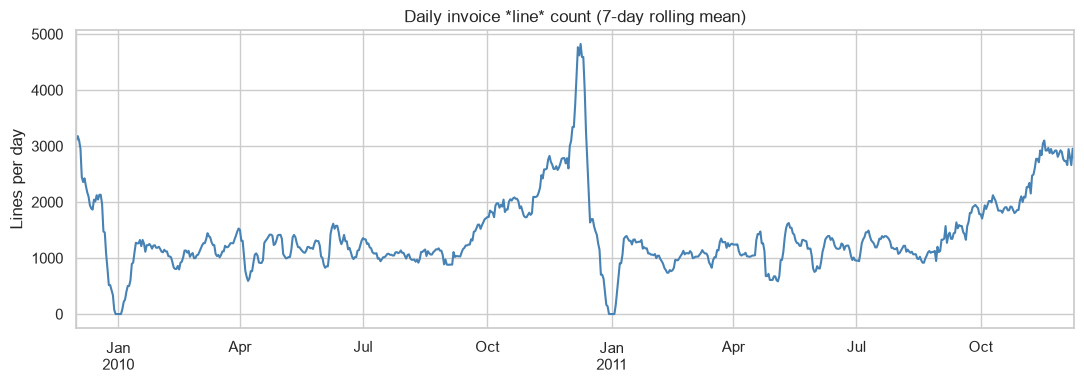

In [3]:
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]

# Harmonize column names across ucimlrepo versions
colmap = {}
for c in df.columns:
    cl = c.lower().replace(" ", "")
    if cl in {"invoice", "invoiceno"}:
        colmap[c] = "Invoice"
    elif cl in {"invoicedate"}:
        colmap[c] = "InvoiceDate"
    elif cl in {"quantity"}:
        colmap[c] = "Quantity"
    elif cl in {"price", "unitprice"}:
        colmap[c] = "Price"
    elif cl in {"customerid", "customer_id"}:
        colmap[c] = "Customer ID"
    elif cl in {"country"}:
        colmap[c] = "Country"
    elif cl in {"stockcode"}:
        colmap[c] = "StockCode"
    elif cl in {"description"}:
        colmap[c] = "Description"
df = df.rename(columns=colmap)

required = {"Invoice", "InvoiceDate", "Quantity", "Price"}
missing = required - set(df.columns)
if missing:
    raise KeyError(f"Missing expected columns after rename: {missing}. Have={list(df.columns)}")

n0 = len(df)
df["Invoice"] = df["Invoice"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

cancel_mask = df["Invoice"].str.startswith("C", na=False)
print(f"Cancellation rows (Invoice starts with C): {cancel_mask.sum():,}")
print(f"Non-positive Quantity: {(df['Quantity'] <= 0).sum():,}")
print(f"Non-positive Price: {(df['Price'] <= 0).sum():,}")
print(f"Null InvoiceDate: {df['InvoiceDate'].isna().sum():,}")

df = df.loc[~cancel_mask].copy()
df = df.dropna(subset=["InvoiceDate", "Quantity", "Price"])
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)].copy()
print(f"Kept {len(df):,} / {n0:,} rows after cleaning")
print(f"Date range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")

daily_orders = df.groupby(df["InvoiceDate"].dt.normalize()).size()
full_daily_idx = pd.date_range(daily_orders.index.min(), daily_orders.index.max(), freq="D")
daily_orders = daily_orders.reindex(full_daily_idx, fill_value=0)
print(f"Calendar days spanned: {len(daily_orders)}")
print(
    f"Days with zero orders: {(daily_orders == 0).sum()} "
    f"({100 * (daily_orders == 0).mean():.1f}%)"
)
print(
    f"Mean orders/day: {daily_orders.mean():.2f} | "
    f"CV: {daily_orders.std() / daily_orders.mean():.2f}"
)

fig, ax = plt.subplots()
daily_orders.rolling(7, min_periods=1).mean().plot(ax=ax, color="steelblue")
ax.set_title("Daily invoice *line* count (7-day rolling mean)")
ax.set_ylabel("Lines per day")
show_plot()

### 3.1 Candidate granularities: daily vs weekly unit demand

Decide grain from **observed** sparsity and variability — do not assume weekly.

,grain,n,mean,std,cv,pct_zero,min,max,start,end
0,daily,739,15453.728011,13431.098791,0.869117,18.267930,0.0,125534.0,2009-12-01,2011-12-09
1,weekly,106,107738.726415,46139.176735,0.428251,1.886792,0.0,248485.0,2009-12-06,2011-12-11


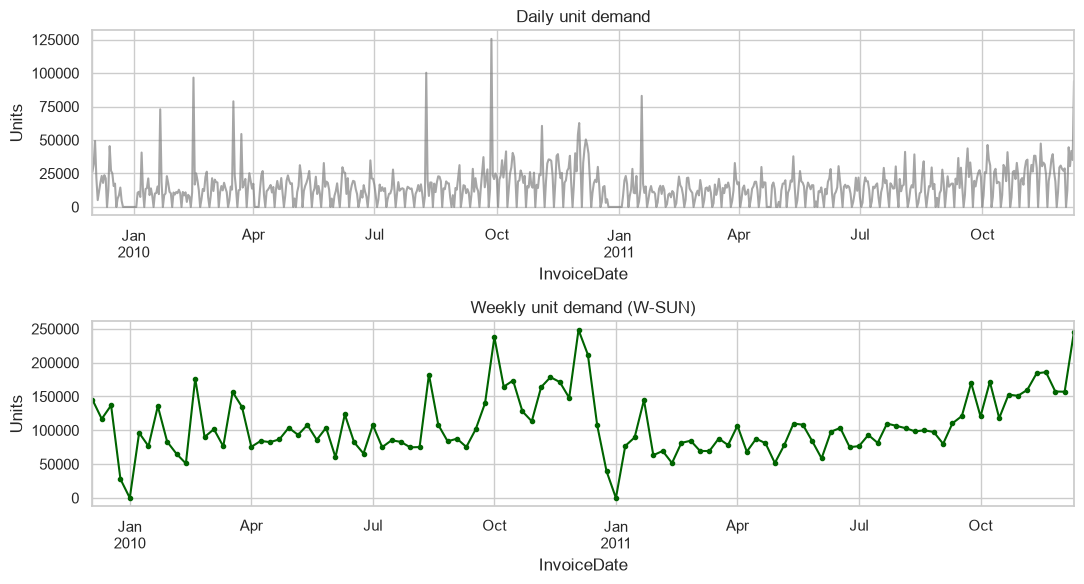


>>> GRANULARITY DECISION: WEEKLY
Daily series has 18.3% zero-demand days and CV=0.87 vs weekly CV=0.43. Weekly aggregation is more stable for planning.
Series length: 106 | 2009-12-06 → 2011-12-11


In [4]:
demand_daily = (
    df.groupby(df["InvoiceDate"].dt.normalize())["Quantity"]
    .sum()
    .rename("demand")
    .asfreq("D", fill_value=0)
    .sort_index()
)
demand_weekly = (
    df.set_index("InvoiceDate")["Quantity"]
    .resample("W-SUN")
    .sum()
    .rename("demand")
    .sort_index()
)
demand_weekly = demand_weekly.loc[
    demand_weekly.ne(0).idxmax() : demand_weekly.ne(0)[::-1].idxmax()
]


def series_profile(s: pd.Series, name: str) -> dict:
    s = s.astype(float)
    return {
        "grain": name,
        "n": int(s.shape[0]),
        "mean": float(s.mean()),
        "std": float(s.std(ddof=1)),
        "cv": float(s.std(ddof=1) / s.mean()) if s.mean() else np.nan,
        "pct_zero": float((s == 0).mean() * 100),
        "min": float(s.min()),
        "max": float(s.max()),
        "start": str(s.index.min().date()),
        "end": str(s.index.max().date()),
    }


profiles = pd.DataFrame([
    series_profile(demand_daily, "daily"),
    series_profile(demand_weekly, "weekly"),
])
display(profiles)

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
demand_daily.plot(ax=axes[0], color="gray", alpha=0.7, title="Daily unit demand")
axes[0].set_ylabel("Units")
demand_weekly.plot(
    ax=axes[1], color="darkgreen", marker="o", ms=3, title="Weekly unit demand (W-SUN)"
)
axes[1].set_ylabel("Units")
show_plot()

daily_pct_zero = profiles.loc[profiles.grain == "daily", "pct_zero"].iloc[0]
daily_cv = profiles.loc[profiles.grain == "daily", "cv"].iloc[0]
weekly_cv = profiles.loc[profiles.grain == "weekly", "cv"].iloc[0]

if daily_pct_zero > 15 or daily_cv > weekly_cv * 1.15:
    GRAIN = "weekly"
    y_full = demand_weekly.copy()
    SEASONAL_PERIOD = 52
    decision_reason = (
        f"Daily series has {daily_pct_zero:.1f}% zero-demand days and CV={daily_cv:.2f} "
        f"vs weekly CV={weekly_cv:.2f}. Weekly aggregation is more stable for planning."
    )
else:
    GRAIN = "daily"
    y_full = demand_daily.copy()
    SEASONAL_PERIOD = 7
    decision_reason = (
        f"Daily series is dense enough (zero days={daily_pct_zero:.1f}%, CV={daily_cv:.2f}); "
        "keeping daily grain."
    )

print(f"\n>>> GRANULARITY DECISION: {GRAIN.upper()}")
print(decision_reason)
print(f"Series length: {len(y_full)} | {y_full.index.min().date()} → {y_full.index.max().date()}")

### 3.2 Trend, seasonality, stationarity

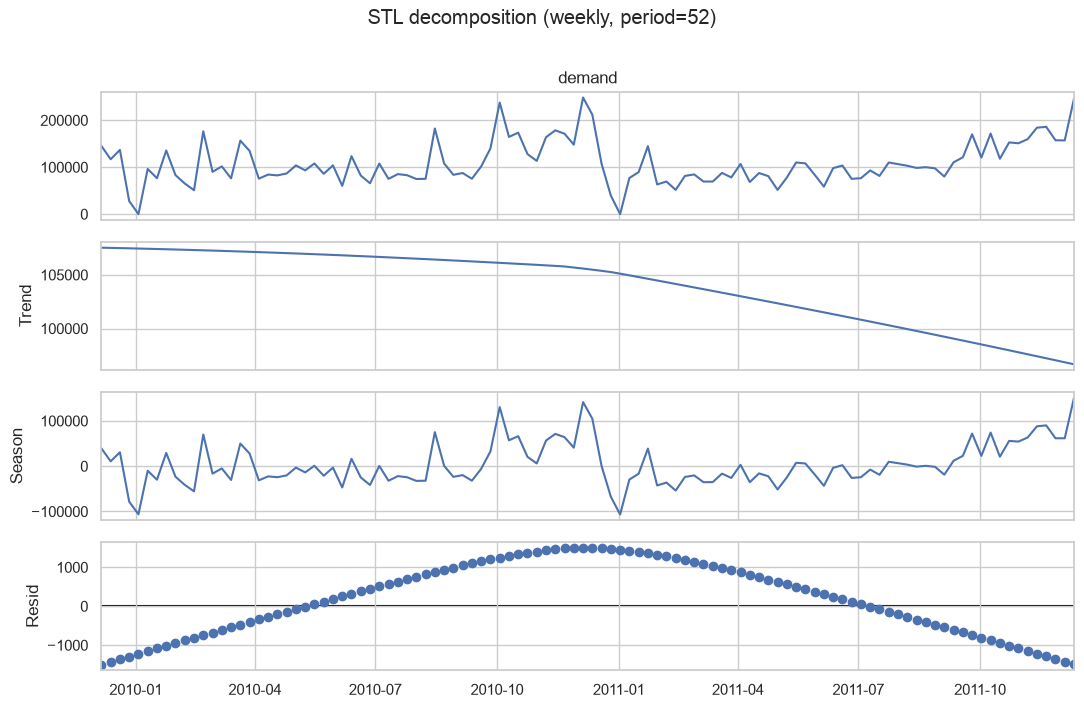

ADF statistic=-5.0532, p-value=1.74e-05
Reject H0 of unit root → series looks stationary (at 5%).


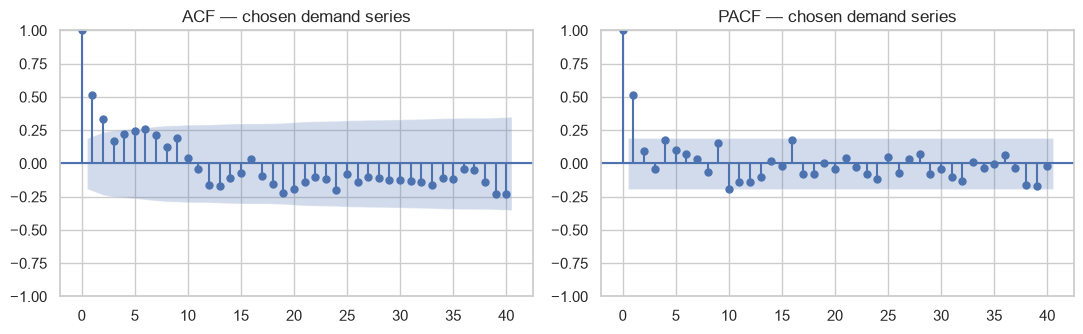

Top countries by units:


,units
Country,
United Kingdom,9383244
Netherlands,383977
EIRE,340289
France,275287
Denmark,237925
Germany,227983
Australia,104090
Sweden,88650
Switzerland,52884


In [5]:
stl_period = SEASONAL_PERIOD
if len(y_full) < 2 * stl_period + 1:
    stl_period = 7
    print(f"Series shorter than 2×{SEASONAL_PERIOD}; using STL period={stl_period}")

stl = STL(y_full.astype(float), period=stl_period, robust=True)
stl_res = stl.fit()
fig = stl_res.plot()
fig.set_size_inches(11, 7)
fig.suptitle(f"STL decomposition ({GRAIN}, period={stl_period})", y=1.01)
show_plot()

adf_stat, adf_p, *_ = adfuller(y_full.astype(float), autolag="AIC")
print(f"ADF statistic={adf_stat:.4f}, p-value={adf_p:.4g}")
if adf_p < 0.05:
    print("Reject H0 of unit root → series looks stationary (at 5%).")
else:
    print("Fail to reject unit root → integration/trend may be present.")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
plot_acf(y_full.astype(float), lags=min(40, len(y_full) // 2 - 1), ax=axes[0])
plot_pacf(
    y_full.astype(float), lags=min(40, len(y_full) // 2 - 1), ax=axes[1], method="ywm"
)
axes[0].set_title("ACF — chosen demand series")
axes[1].set_title("PACF — chosen demand series")
show_plot()

if "Country" in df.columns:
    top_c = df.groupby("Country")["Quantity"].sum().sort_values(ascending=False).head(10)
    print("Top countries by units:")
    display(top_c.to_frame("units"))

## 4. Target series + time-ordered holdout

Grain=weekly | H=8 | seasonal_period candidate=52
Train: 2009-12-06 → 2011-10-16 (n=98)
Test : 2011-10-23 → 2011-12-11 (n=8)
Train mean demand: 102308.4 units / period
Test  mean demand: 174260.6 units / period


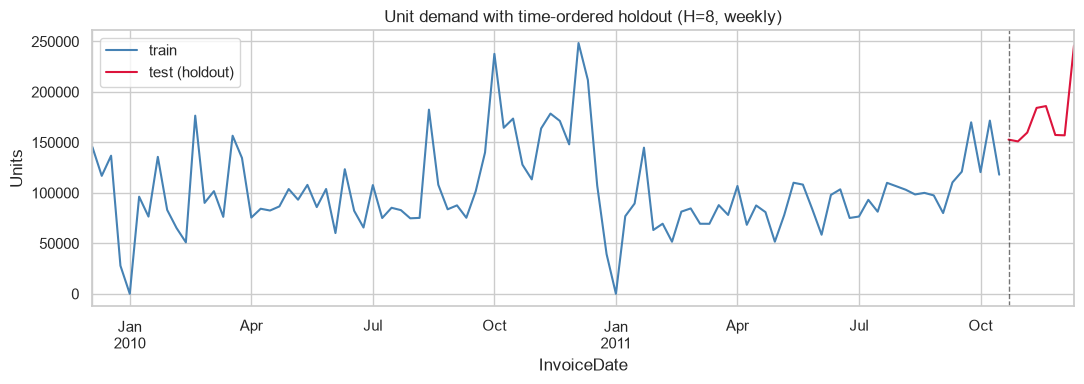

In [6]:
H = 8 if GRAIN == "weekly" else 28
if len(y_full) <= H + 20:
    H = max(4, len(y_full) // 5)
    print(f"Short series — reducing H to {H}")

y = y_full.astype(float).copy()
y.name = "demand"
y_train = y.iloc[:-H]
y_test = y.iloc[-H:]

print(f"Grain={GRAIN} | H={H} | seasonal_period candidate={SEASONAL_PERIOD}")
print(f"Train: {y_train.index.min().date()} → {y_train.index.max().date()} (n={len(y_train)})")
print(f"Test : {y_test.index.min().date()} → {y_test.index.max().date()} (n={len(y_test)})")
print(f"Train mean demand: {y_train.mean():.1f} units / period")
print(f"Test  mean demand: {y_test.mean():.1f} units / period")

fig, ax = plt.subplots()
y_train.plot(ax=ax, label="train", color="steelblue")
y_test.plot(ax=ax, label="test (holdout)", color="crimson")
ax.axvline(y_test.index[0], color="k", ls="--", lw=1, alpha=0.6)
ax.set_title(f"Unit demand with time-ordered holdout (H={H}, {GRAIN})")
ax.set_ylabel("Units")
ax.legend()
show_plot()


def forecast_metrics(
    y_true: np.ndarray, y_pred: np.ndarray, y_train_arr: np.ndarray, m: int
) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_train_arr = np.asarray(y_train_arr, dtype=float)
    err = y_true - y_pred
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    denom = np.maximum(np.abs(y_true), 1e-8)
    mape = float(np.mean(np.abs(err) / denom) * 100)
    m = max(1, min(m, len(y_train_arr) // 2))
    scale = np.mean(np.abs(y_train_arr[m:] - y_train_arr[:-m]))
    if not np.isfinite(scale) or scale < 1e-8:
        scale = np.mean(np.abs(np.diff(y_train_arr))) + 1e-8
    mase = float(mae / scale)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "MASE": mase}

## 5. Part 1 — PyCaret survey (MASE-ranked)

Same OOP API as notebook 1:
`TimeSeriesExperiment` → `fit(y_train)` → `compare_models(sort="MASE")`
→ `CompareResult.best / .leaderboard / .ranked_ids`.

In [7]:
from pycaret.time_series import TimeSeriesExperiment

if GRAIN == "weekly":
    sp_for_exp = 4  # practical short cycle for survey speed
else:
    sp_for_exp = 7
if len(y_train) < 2 * sp_for_exp:
    sp_for_exp = max(1, len(y_train) // 4)
print(
    f"PyCaret seasonal_period={sp_for_exp} "
    f"(EDA used ~{SEASONAL_PERIOD}; survey uses a faster cycle)"
)

exp = TimeSeriesExperiment(
    fh=H,
    session_id=SEED,
    fold=2,
    fold_strategy="expanding",
    seasonal_period=sp_for_exp,
    verbose=False,
    n_jobs=1,
)
exp.fit(y_train)

print("Registered models (sample):")
try:
    display(exp.models())
except Exception as exc:  # noqa: BLE001
    print("models() unavailable:", exc)

SURVEY_INCLUDE = [
    "naive",
    "snaive",
    "grand_means",
    "polytrend",
    "arima",
    "exp_smooth",
    "ets",
    "theta",
    "croston",
]
print(f"\nRunning compare_models(sort='MASE', include={SURVEY_INCLUDE})…")
compare_result = exp.compare_models(
    sort="MASE",
    include=SURVEY_INCLUDE,
    turbo=True,
    n_select=1,
    verbose=False,
)

leaderboard = compare_result.leaderboard.copy()
if "MASE" in leaderboard.columns:
    leaderboard_valid = leaderboard.dropna(subset=["MASE"]).reset_index(drop=True)
else:
    leaderboard_valid = leaderboard

print("\n=== PyCaret leaderboard (MASE-sorted; lower is better) ===")
display(leaderboard_valid)

if leaderboard_valid.empty or compare_result.best is None:
    raise RuntimeError(f"PyCaret compare_models failed. Raw leaderboard:\n{leaderboard}")

winner_id = str(compare_result.ranked_ids[0])
winner_row = leaderboard_valid.iloc[0]
print(f"\n>>> PYCARET WINNER: {winner_id}")
print(winner_row.to_string())

PyCaret seasonal_period=4 (EDA used ~52; survey uses a faster cycle)


Registered models (sample):


,Name,Reference,Turbo
ID,,,
naive,Naive Forecaster,sktime.forecasting.naive._naive.NaiveForecaster,True
grand_means,Grand Means Forecaster,sktime.forecasting.naive._naive.NaiveForecaster,True
polytrend,Polynomial Trend Forecaster,sktime.forecasting.trend._polynomial_trend_for...,True
arima,ARIMA,sktime.forecasting.arima._pmdarima.ARIMA,True
auto_arima,Auto ARIMA,sktime.forecasting.arima._pmdarima.AutoARIMA,True
exp_smooth,Exponential Smoothing,sktime.forecasting.exp_smoothing.ExponentialSm...,True
ets,ETS,sktime.forecasting.ets.AutoETS,True
theta,Theta Forecaster,sktime.forecasting.theta.ThetaForecaster,True
croston,Croston,sktime.forecasting.croston.Croston,True



Running compare_models(sort='MASE', include=['naive', 'snaive', 'grand_means', 'polytrend', 'arima', 'exp_smooth', 'ets', 'theta', 'croston'])…



=== PyCaret leaderboard (MASE-sorted; lower is better) ===


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,COVERAGE
0,arima,1.4841,1.0620,63174.7338,65797.6238,0.6888,1.0628,-17.0475,1.0
1,grand_means,1.5015,1.0696,63873.6338,66240.8052,0.6977,1.0804,-17.6101,1.0
2,theta,2.1043,1.4883,89693.0102,92298.2334,0.9940,1.8259,-33.1397,1.0
3,naive,3.6555,2.6771,155956.7537,166118.3086,1.7155,1.9252,-107.2635,1.0



>>> PYCARET WINNER: arima
Model            arima
MASE            1.4841
RMSSE            1.062
MAE         63174.7338
RMSE        65797.6238
MAPE            0.6888
SMAPE           1.0628
R2            -17.0475
COVERAGE           1.0


## 6. Production classical + foundation bake-off

Online Retail II has ~2 years of weekly history — **annual m=52** may not fit
two full cycles on train, so the bake-off also tries **m=13 / 26** (quarterly /
semi-annual weeks). Production systems should auto-search seasonal periods that
fit the sample length (see `demand_forecast.classical.seasonal_periods_for_series`).

=== Production notes ===
 - grain=weekly h=8 n=106 train=98 test=8
 - MASE seasonal period=52
 - validation MAE (last H of train): timesfm_2p5_zeroshot=2.07e+04, holt_winters_add_m26=2.41e+04, holt_winters_mul_m26=2.48e+04, holt_winters_mul_m4=2.65e+04, auto_arima_m4=2.89e+04, holt_winters_mul_m8=2.93e+04, seasonal_naive_m4=2.96e+04, holt_winters_add_m8=3.23e+04, holt_winters_add_m4=3.3e+04, seasonal_naive_m52=3.57e+04, holt_winters_mul_m13=3.65e+04, holt_winters_add_m13=4.02e+04
 - ensemble weights: seasonal_naive_m52:0.07, seasonal_naive_m4:0.08, holt_winters_add_m4:0.07, holt_winters_mul_m4:0.09, holt_winters_add_m8:0.08, holt_winters_mul_m8:0.08, holt_winters_add_m13:0.06, holt_winters_mul_m13:0.07, holt_winters_add_m26:0.10, holt_winters_mul_m26:0.10, auto_arima_m4:0.08, timesfm_2p5_zeroshot:0.12
 - rolling origin=0 local-best=holt_winters_mul_m13 MASE=0.5613
 - rolling origin=1 local-best=timesfm_2p5_zeroshot MASE=0.4482
 - rolling origin=2 local-best=auto_arima_m4 MASE=0.1363

=

,MAE,RMSE,MAPE,sMAPE,MASE,bias,kind,val_MAE,PI_coverage
holt_winters_mul_m13,22453.1428,29926.3169,11.9098,12.9235,0.5613,-18411.3872,classical,36530.1772,0.875
holt_winters_mul_m8,27624.0104,41807.4148,13.8789,15.9297,0.6905,-23466.5147,classical,29334.7595,0.750
seasonal_naive_m52,27724.0000,38595.7396,16.5917,15.7669,0.6930,-3837.7500,classical,35712.5000,0.875
holt_winters_mul_m26,30226.5094,34464.0237,16.8256,18.4558,0.7556,-25044.2072,classical,24756.4661,0.875
holt_winters_add_m13,30322.7942,39701.7169,16.1073,18.1984,0.7580,-30322.7942,classical,40235.1315,0.875
holt_winters_add_m26,30654.8651,33829.9342,17.1140,18.8329,0.7663,-26900.3416,classical,24096.8608,0.875
timesfm_2p5_zeroshot,31731.9473,40346.5195,16.8794,18.9899,0.7932,-27765.7012,foundation,20721.2578,0.875
ensemble_inv_val_mae,32028.8623,40862.9910,16.8862,19.0652,0.8006,-30825.4186,ensemble,NaN,0.875
holt_winters_mul_m4,33592.4013,44246.8781,17.4887,20.1051,0.8397,-33592.4013,classical,26529.2873,0.750
holt_winters_add_m8,38149.9067,50877.5051,19.7664,23.2235,0.9536,-38149.9067,classical,32302.0440,0.750



>>> PRODUCTION CHAMPION: holt_winters_mul_m13 (classical)
Details: ExponentialSmoothing trend=add seasonal=mul period=13
{'MAE': 22453.1428, 'RMSE': 29926.3169, 'MAPE': 11.9098, 'sMAPE': 12.9235, 'MASE': 0.5613, 'bias': -18411.3872}
PI coverage: 0.875


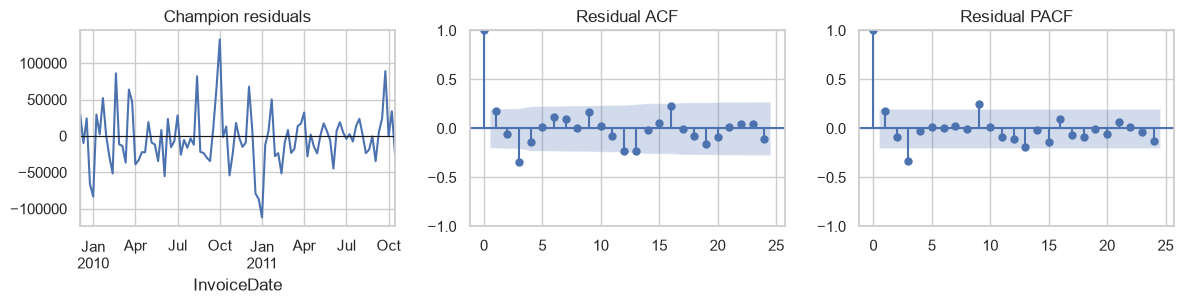

Ljung-Box:


,lb_stat,lb_pvalue
10,23.453559,0.009191


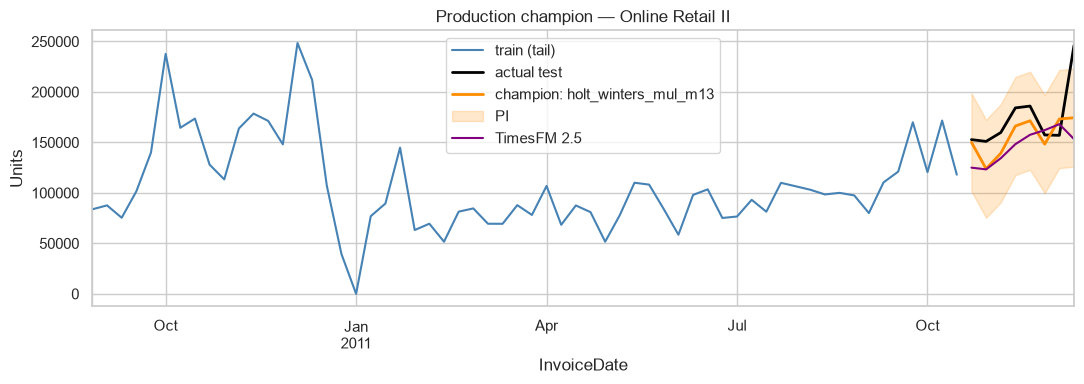

In [8]:
from demand_forecast import run_production_bakeoff
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

prod = run_production_bakeoff(
    y,
    grain=GRAIN,
    h=H,
    seed=SEED,
    n_rolling_origins=3,
    include_timesfm=True,
)

print("=== Production notes ===")
for note in prod.notes:
    print(" -", note)

print("\n=== Holdout leaderboard (sorted by MASE) ===")
display(prod.leaderboard.round(4))

champ = prod.champion
print(f"\n>>> PRODUCTION CHAMPION: {champ.name} ({champ.kind})")
print(f"Details: {champ.details}")
print({k: round(v, 4) for k, v in champ.test_metrics.items()})
print(f"PI coverage: {champ.coverage}")

champ_fc = pd.Series(champ.point, index=y_test.index, name=champ.name)
champ_lo = pd.Series(champ.lower, index=y_test.index)
champ_hi = pd.Series(champ.upper, index=y_test.index)
tfm_row = next((c for c in prod.candidates if c.name.startswith("timesfm")), None)

if champ.residuals is not None and len(champ.residuals.dropna()) > 10:
    resid = champ.residuals.dropna()
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
    resid.plot(ax=axes[0], title="Champion residuals")
    axes[0].axhline(0, color="k", lw=0.8)
    plot_acf(resid, lags=min(24, len(resid) // 2 - 1), ax=axes[1])
    plot_pacf(resid, lags=min(24, len(resid) // 2 - 1), ax=axes[2], method="ywm")
    axes[1].set_title("Residual ACF")
    axes[2].set_title("Residual PACF")
    show_plot()
    lb = acorr_ljungbox(resid, lags=[min(10, max(1, len(resid) // 5))], return_df=True)
    print("Ljung-Box:")
    display(lb)
else:
    print("No classical residuals on champion — skip Ljung-Box.")

fig, ax = plt.subplots(figsize=(11, 4))
y_train.iloc[-min(60, len(y_train)):].plot(ax=ax, label="train (tail)", color="steelblue")
y_test.plot(ax=ax, label="actual test", color="black", lw=2)
champ_fc.plot(ax=ax, label=f"champion: {champ.name}", color="darkorange", lw=2)
ax.fill_between(y_test.index, champ_lo, champ_hi, color="darkorange", alpha=0.2, label="PI")
if tfm_row is not None and tfm_row.name != champ.name:
    pd.Series(tfm_row.point, index=y_test.index).plot(ax=ax, label="TimesFM 2.5", color="purple", lw=1.5)
ax.set_title("Production champion — Online Retail II")
ax.set_ylabel("Units")
ax.legend()
show_plot()

## 7. Rolling-origin robustness

=== Rolling-origin mean metrics ===


,MAE,RMSE,MAPE,MASE
model,,,,
timesfm_2p5_zeroshot,21561.7738,27397.4545,14.7028,0.4980
holt_winters_mul_m8,23608.7096,32262.5516,17.2618,0.5372
holt_winters_mul_m13,24037.1295,31292.3463,17.3667,0.5409
holt_winters_mul_m4,23872.5243,31817.2955,16.0148,0.5504
holt_winters_add_m13,28875.1141,36937.0614,20.4385,0.6534
holt_winters_add_m4,28743.4271,36923.2728,19.5712,0.6622
holt_winters_add_m26,29967.6959,33611.0146,24.3264,0.6712
holt_winters_add_m8,29546.3781,37989.0097,21.0504,0.6760
seasonal_naive_m52,30805.7917,41705.2280,25.4137,0.6881


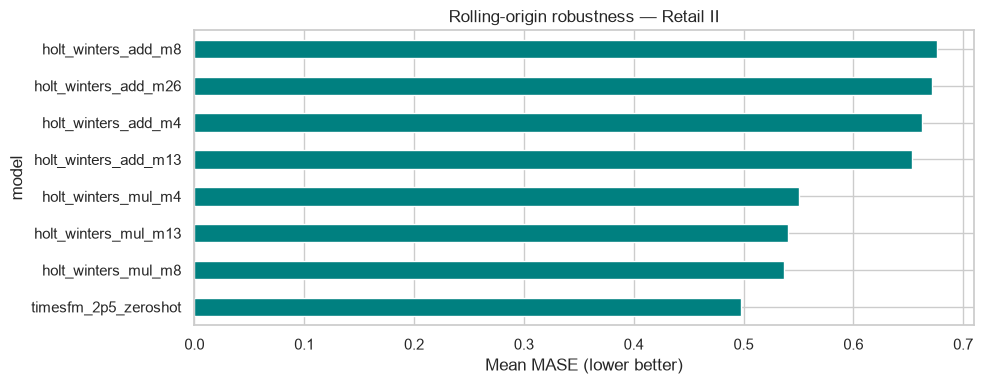

In [9]:
if prod.rolling is not None and len(prod.rolling):
    roll_mean = (
        prod.rolling.groupby("model")[["MAE", "RMSE", "MAPE", "MASE"]]
        .mean()
        .sort_values("MASE")
    )
    print("=== Rolling-origin mean metrics ===")
    display(roll_mean.round(4))
    fig, ax = plt.subplots(figsize=(10, 4))
    roll_mean.head(8)["MASE"].plot(kind="barh", ax=ax, color="teal")
    ax.set_xlabel("Mean MASE (lower better)")
    ax.set_title("Rolling-origin robustness — Retail II")
    show_plot()
else:
    print("No rolling-origin rows.")

## 8. Comparison table + interpretation

Full production leaderboard:


,MAE,RMSE,MAPE,sMAPE,MASE,bias,kind,val_MAE,PI_coverage
holt_winters_mul_m13,22453.1428,29926.3169,11.9098,12.9235,0.5613,-18411.3872,classical,36530.1772,0.875
holt_winters_mul_m8,27624.0104,41807.4148,13.8789,15.9297,0.6905,-23466.5147,classical,29334.7595,0.750
seasonal_naive_m52,27724.0000,38595.7396,16.5917,15.7669,0.6930,-3837.7500,classical,35712.5000,0.875
holt_winters_mul_m26,30226.5094,34464.0237,16.8256,18.4558,0.7556,-25044.2072,classical,24756.4661,0.875
holt_winters_add_m13,30322.7942,39701.7169,16.1073,18.1984,0.7580,-30322.7942,classical,40235.1315,0.875
holt_winters_add_m26,30654.8651,33829.9342,17.1140,18.8329,0.7663,-26900.3416,classical,24096.8608,0.875
timesfm_2p5_zeroshot,31731.9473,40346.5195,16.8794,18.9899,0.7932,-27765.7012,foundation,20721.2578,0.875
ensemble_inv_val_mae,32028.8623,40862.9910,16.8862,19.0652,0.8006,-30825.4186,ensemble,NaN,0.875
holt_winters_mul_m4,33592.4013,44246.8781,17.4887,20.1051,0.8397,-33592.4013,classical,26529.2873,0.750
holt_winters_add_m8,38149.9067,50877.5051,19.7664,23.2235,0.9536,-38149.9067,classical,32302.0440,0.750



Champion **holt_winters_mul_m13** MASE=0.5613, MAE=22453.1, MAPE=11.91%.
TimesFM MASE=0.7932. On short retail panels, a seasonal classical model with a period that fits the sample (e.g. m=13) can beat both short-cycle ARIMA and zero-shot FMs.
PyCaret educational winner: arima (short-cycle survey).


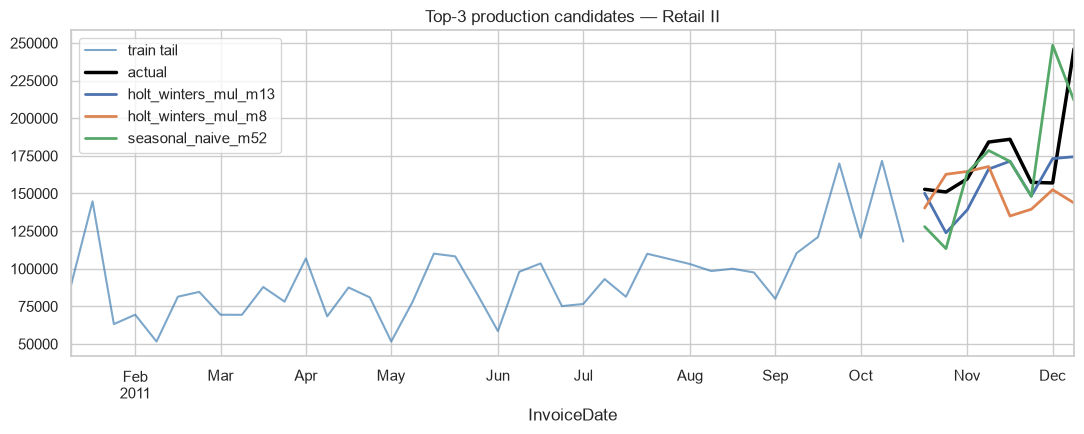

Wrote /home/ahmad/AI/Demand Forecasting for Inventory Planning/data/results/online_retail_ii_production_metrics.csv


In [10]:
print("Full production leaderboard:")
display(prod.leaderboard.round(4))
print(
    f"\nChampion **{champ.name}** MASE={champ.test_metrics['MASE']:.4f}, "
    f"MAE={champ.test_metrics['MAE']:.1f}, MAPE={champ.test_metrics['MAPE']:.2f}%."
)
if tfm_row is not None:
    print(
        f"TimesFM MASE={tfm_row.test_metrics['MASE']:.4f}. "
        "On short retail panels, a seasonal classical model with a period that fits "
        "the sample (e.g. m=13) can beat both short-cycle ARIMA and zero-shot FMs."
    )
print(f"PyCaret educational winner: {winner_id} (short-cycle survey).")

fig, ax = plt.subplots(figsize=(11, 4.5))
y_train.iloc[-min(40, len(y_train)):].plot(ax=ax, color="steelblue", alpha=0.7, label="train tail")
y_test.plot(ax=ax, color="black", lw=2.5, label="actual")
for c in sorted(prod.candidates, key=lambda x: x.test_metrics["MASE"])[:3]:
    pd.Series(c.point, index=y_test.index).plot(ax=ax, lw=2, label=c.name)
ax.set_title("Top-3 production candidates — Retail II")
ax.legend()
show_plot()

results_dir = _ROOT / "data" / "results"
results_dir.mkdir(parents=True, exist_ok=True)
out_path = results_dir / "online_retail_ii_production_metrics.csv"
prod.leaderboard.to_csv(out_path)
print(f"Wrote {out_path}")

## 9. Inventory-planning takeaway

In [11]:
mean_actual = float(y_test.mean())
avg_point = float(champ_fc.mean())
avg_lo = float(champ_lo.mean())
avg_hi = float(champ_hi.mean())
print("=== Inventory-facing summary ===")
print(f"Grain={GRAIN} H={H} champion={champ.name}")
print(f"Holdout mean actual: {mean_actual:.1f} units/week")
print(f"Point / PI: {avg_point:.1f}  [{avg_lo:.1f}, {avg_hi:.1f}]")
print(
    f"Plan baseline near {avg_point:.0f} units/week; service-minded cover toward "
    f"{avg_hi:.0f}. Bias={champ.test_metrics['bias']:.1f}. "
    "Directional only — not a full safety-stock formula."
)
print(decision_reason)
print(f"PyCaret survey winner: {winner_id} | Production champion: {champ.name}")
print("Notebook 02 complete (production bake-off).")

=== Inventory-facing summary ===
Grain=weekly H=8 champion=holt_winters_mul_m13
Holdout mean actual: 174260.6 units/week
Point / PI: 155849.2  [107247.5, 204450.9]
Plan baseline near 155849 units/week; service-minded cover toward 204451. Bias=-18411.4. Directional only — not a full safety-stock formula.
Daily series has 18.3% zero-demand days and CV=0.87 vs weekly CV=0.43. Weekly aggregation is more stable for planning.
PyCaret survey winner: arima | Production champion: holt_winters_mul_m13
Notebook 02 complete (production bake-off).
